In [3]:
!pip install -r ../requirements.txt

  Using cached geopandas-1.1.3-py3-none-any.whl.metadata (2.3 kB)
  Using cached shapely-2.1.2-cp313-cp313-win_amd64.whl.metadata (7.1 kB)
  Using cached pyproj-3.7.2-cp313-cp313-win_amd64.whl.metadata (31 kB)
  Using cached pyogrio-0.12.1-cp313-cp313-win_amd64.whl.metadata (6.0 kB)
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached geopandas-1.1.3-py3-none-any.whl (342 kB)
Using cached shapely-2.1.2-cp313-cp313-win_amd64.whl (1.7 MB)
Using cached pyproj-3.7.2-cp313-cp313-win_amd64.whl (6.3 MB)
Using cached pyogrio-0.12.1-cp313-cp313-win_amd64.whl (22.9 MB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)

   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [sha


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_parquet("../data/processed/PFOS.parquet")

print(gdf.shape)
gdf.head()

(22846, 4)


,lat,lon,value,geometry
0,-21.364356,55.733356,11.700000,POINT (55.73336 -21.36436)
1,-21.354096,55.623506,0.500000,POINT (55.62351 -21.3541)
2,-21.330124,55.487014,0.783333,POINT (55.48701 -21.33012)
3,-21.325085,55.474879,2.342857,POINT (55.47488 -21.32508)
4,-21.310517,55.468648,0.800000,POINT (55.46865 -21.31052)


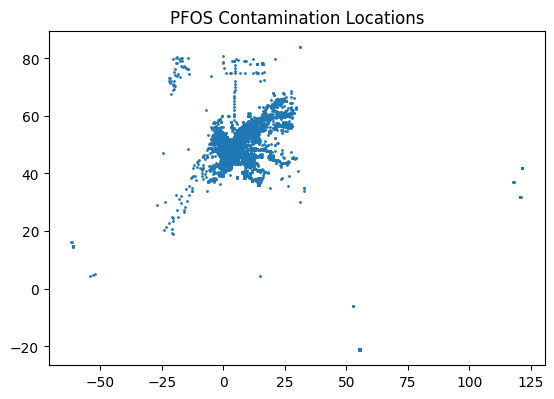

In [5]:
gdf.plot(markersize=1)
plt.title("PFOS Contamination Locations")
plt.show()

In [6]:
from sklearn.cluster import DBSCAN

coords = gdf[["lat","lon"]]

db = DBSCAN(eps=0.5, min_samples=10)
gdf["cluster"] = db.fit_predict(coords)

print(gdf["cluster"].value_counts())

cluster
 10    20754
-1       977
 29      113
 30       99
 22       84
 9        79
 0        51
 6        50
 32       49
 2        48
 26       39
 24       39
 7        37
 14       37
 8        36
 20       31
 16       29
 4        23
 33       22
 5        21
 18       21
 19       20
 15       17
 17       17
 25       16
 27       15
 3        14
 35       13
 13       13
 11       12
 1        11
 21       11
 23       11
 31       11
 12       10
 34       10
 28        6
Name: count, dtype: int64


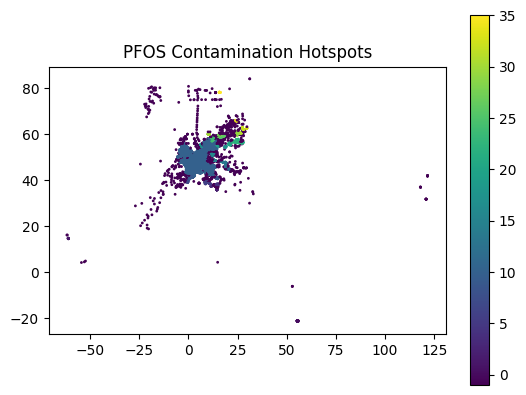

In [7]:
gdf.plot(column="cluster", legend=True, markersize=1)
plt.title("PFOS Contamination Hotspots")
plt.show()

In [1]:
import pandas as pd

df = pd.read_parquet("../data/raw/processed_PFAs.parquet")

df.shape

(3815352, 17)

In [9]:
# 1. Standardize column names (lowercase and replace spaces with underscores)
df.columns = df.columns.str.lower().str.replace(" ", "_")

# 2. Drop rows with missing spatial coordinates and missing values
df = df.dropna(subset=["lat", "lon"])
df = df.dropna(subset=["value"])

# 3. Drop unnecessary columns to go from 17 columns down to 15
df = df.drop(columns=["sector", "city"])

# Check the new shape
print(df.shape)


KeyError: "['sector', 'city'] not found in axis"

In [8]:
from sklearn.cluster import DBSCAN
import numpy as np

print("Running optimized DBSCAN...")

# 1. Filter for significant contamination (e.g., PFOS > 10.0 ng/L is high for many standards)
# This ensures we are clustering *toxic* sites, not just *sampled* sites.
# We create a copy to avoid SettingWithCopyWarnings
high_contamination = gdf[gdf["value"] > 10].copy()

if len(high_contamination) < 5:
    print("Not enough high-contamination points to form stable clusters.")
else:
    # 2. Extract coordinates and convert directly to Radians for Haversine
    coords = high_contamination[["lat", "lon"]]
    coords_radians = np.radians(coords)
    
    # 3. Set DBSCAN Parameters for Earth Geometry
    # We want points within a 5 km radius to cluster together
    epsilon_km = 5.0 
    earth_radius_km = 6371.0088
    epsilon_radians = epsilon_km / earth_radius_km
    
    # 4. Run DBSCAN with Haversine metric and Ball Tree algorithm (for spherical spaces)
    db = DBSCAN(eps=epsilon_radians, min_samples=5, metric='haversine', algorithm='ball_tree')
    high_contamination["cluster"] = db.fit_predict(coords_radians)
    
    print(f"Total high-contamination sites: {len(high_contamination)}")
    print("Hotspot Cluster Breakdown:")
    print(high_contamination["cluster"].value_counts())
    
    # 5. Add the cluster labels back to our main geodataframe
    # Default everything to -999 (not clustered/low concern)
    gdf["cluster"] = -999
    
    # Use the index of high_contamination to map the clusters back to the original rows
    gdf.loc[high_contamination.index, "cluster"] = high_contamination["cluster"]


Running optimized DBSCAN...


NameError: name 'gdf' is not defined

In [1]:
from sklearn.cluster import DBSCAN
import geopandas as gpd
import numpy as np

# 1. Load the data (so 'gdf' is defined)
gdf = gpd.read_parquet("../data/processed/PFOS.parquet")

print("Running optimized DBSCAN...")

# 2. Filter for significant contamination (e.g., PFOS > 10.0 ng/L is high for many standards)
# This ensures we are clustering *toxic* sites, not just *sampled* sites.
high_contamination = gdf[gdf["value"] > 10].copy()

if len(high_contamination) < 5:
    print("Not enough high-contamination points to form stable clusters.")
else:
    # 3. Extract coordinates and convert directly to Radians for Haversine
    coords = high_contamination[["lat", "lon"]]
    coords_radians = np.radians(coords)
    
    # 4. Set DBSCAN Parameters for Earth Geometry
    # We want points within a 5 km radius to cluster together
    epsilon_km = 5.0 
    earth_radius_km = 6371.0088
    epsilon_radians = epsilon_km / earth_radius_km
    
    # 5. Run DBSCAN with Haversine metric and Ball Tree algorithm (for spherical spaces)
    db = DBSCAN(eps=epsilon_radians, min_samples=5, metric='haversine', algorithm='ball_tree')
    high_contamination["cluster"] = db.fit_predict(coords_radians)
    
    print(f"Total high-contamination sites: {len(high_contamination)}")
    print("Hotspot Cluster Breakdown:")
    print(high_contamination["cluster"].value_counts())
    
    # 6. Add the cluster labels back to our main geodataframe
    # Default everything to -999 (not clustered/low concern)
    gdf["cluster"] = -999
    
    # Use the index of high_contamination to map the clusters back to the original rows
    gdf.loc[high_contamination.index, "cluster"] = high_contamination["cluster"]


Running optimized DBSCAN...
Total high-contamination sites: 11268
Hotspot Cluster Breakdown:
cluster
 32     3056
-1      2974
 100    1658
 35      839
 8       533
        ... 
 2         4
 17        4
 94        4
 59        4
 74        4
Name: count, Length: 161, dtype: int64


C:\Users\POORVI RAI K\AppData\Local\Temp\ipykernel_3848\3611363507.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


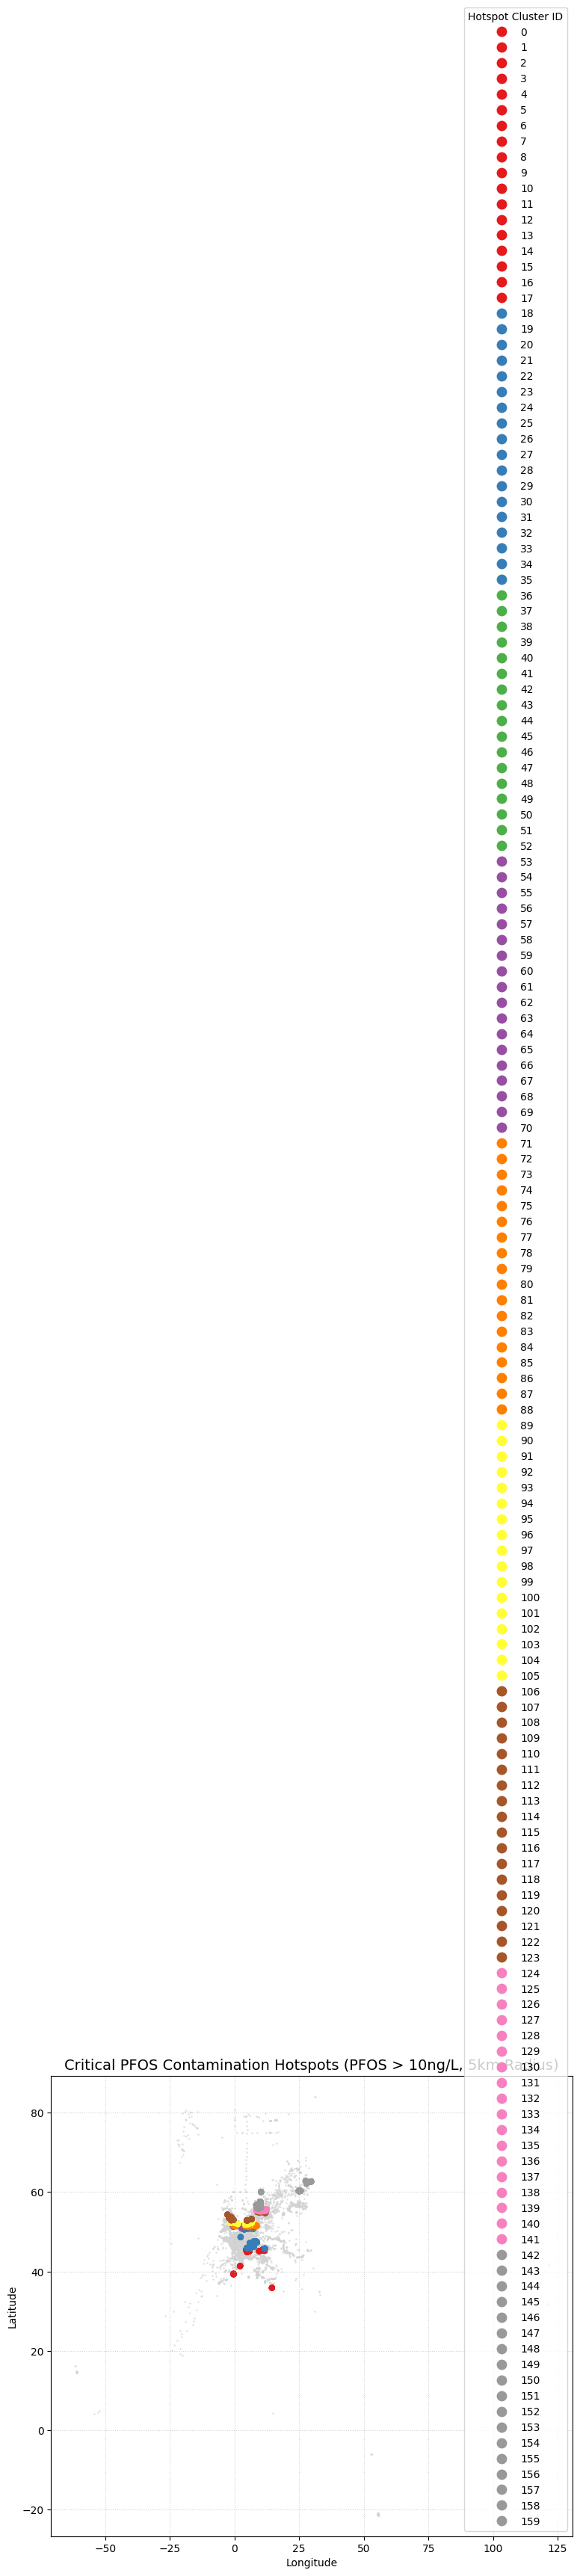

In [ ]:
import matplotlib.pyplot as plt

# 1. Create a large, readable figure
fig, ax = plt.subplots(figsize=(12, 8))

# 2. Separate the data into "Hotspots" and "Background"
# In DBSCAN, -1 means "Noise" (isolated points), and we set -999 as low contamination.
# So valid clusters are any numbers >= 0.
hotspots = gdf[gdf["cluster"] >= 0].copy()
background = gdf[gdf["cluster"] < 0].copy()

# 3. Plot the background faintly
background.plot(ax=ax, markersize=1, color="lightgray", alpha=0.5)

# 4. Plot the actual hotspots
if not hotspots.empty:
    hotspots.plot(
        ax=ax, 
        column="cluster", 
        categorical=True,  
        cmap="Set1",
        markersize=25,
        legend=True,
        legend_kwds={"title": "Hotspot Cluster ID", "loc": "lower right"}
    )

# 5. Add labels and formatting
plt.title("Critical PFOS Contamination Hotspots (PFOS > 10ng/L, 5km Radius)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()
